# Industry Intelligence & Predictive Risk

Explore Swiss industries, browse sanctions databases, score companies
with predictive dissolution models, and generate AI-powered industry
reports. Uses VynCo API v3.2+ endpoints.

```bash
pip install vynco matplotlib seaborn
```

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
import vynco

sns.set_theme(style="whitegrid", font_scale=1.1)
COLORS = ["#1e3a5f", "#2e86ab", "#a23b72", "#f18f01", "#c73e1d",
          "#3b1f2b", "#44bba4", "#e94f37", "#393e41", "#8d6a9f"]
ACCENT = "#2e86ab"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

client = vynco.Client()
print(f"VynCo SDK v{vynco.__version__} — connected")

VynCo SDK v3.2.0 — connected


## 1. Industry Landscape

How many industries does VynCo track? Which are the largest?

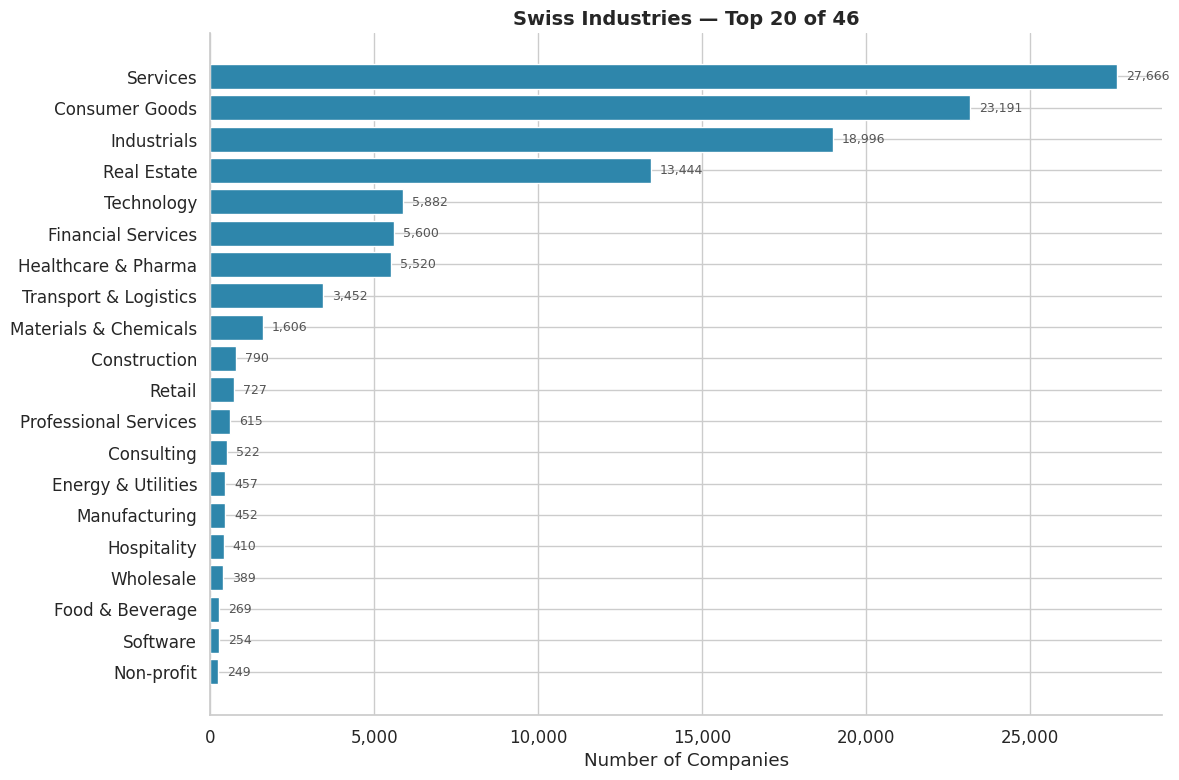

Total: 46 industries, 112,460 companies


In [2]:
industries = client.reports.industries().data

sorted_ind = sorted(industries.industries, key=lambda i: -i.company_count)[:20]
names = [i.industry for i in sorted_ind]
counts = [i.company_count for i in sorted_ind]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(names[::-1], counts[::-1], color=ACCENT, edgecolor="white")
for bar, count in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + max(counts) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{count:,}", va="center", fontsize=9, color="#555")

ax.set_xlabel("Number of Companies")
ax.set_title(f"Swiss Industries — Top 20 of {industries.total}",
             fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/industry_landscape.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Total: {industries.total} industries, {sum(i.company_count for i in industries.industries):,} companies")

## 2. Industry Deep Dive

Pick the largest industry and explore its structure — capital distribution,
canton spread, auditor concentration.

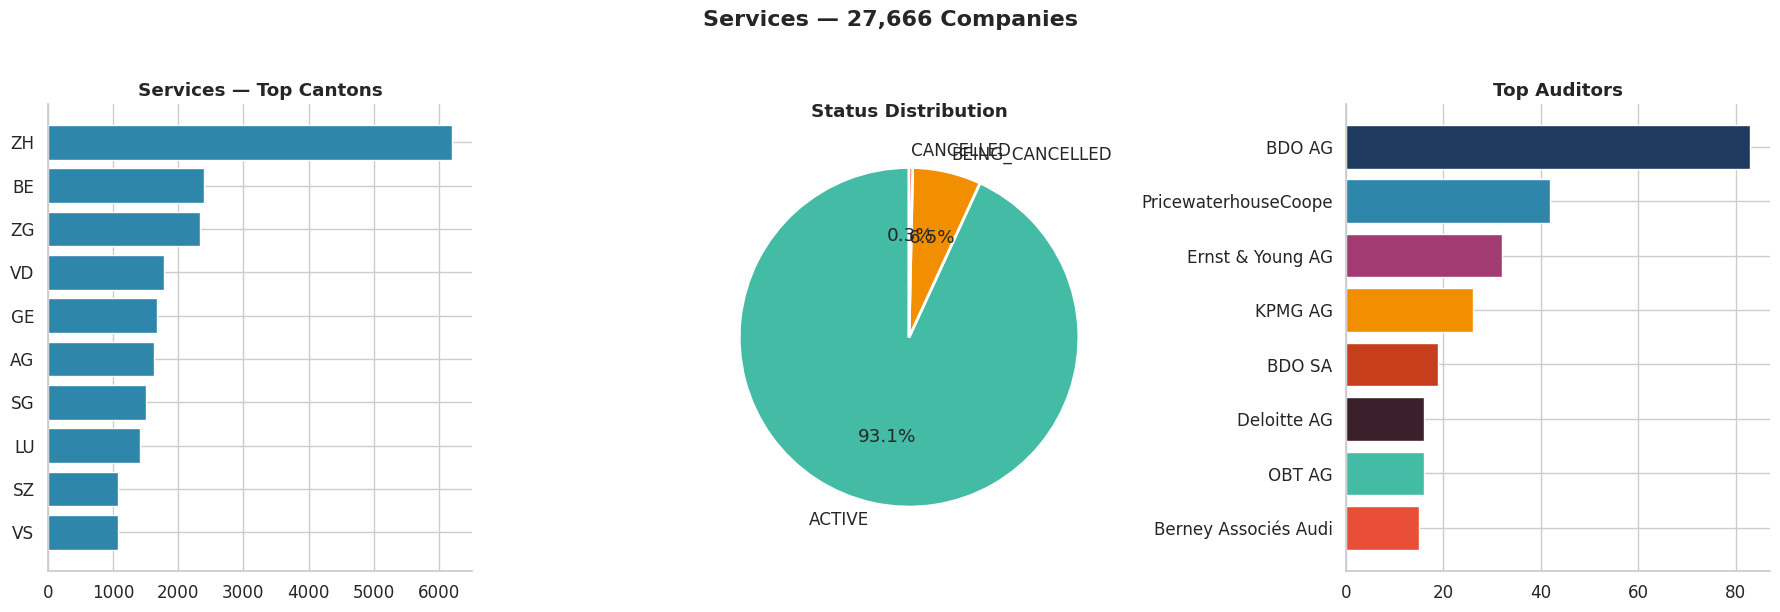


Capital: avg=121,466 CHF, median=20,000 CHF
Recent changes (30d): 26,877

Top companies by capital:
  Swiss Education Group Holding Ltd                  ZG   145,824,500 CHF
  KER INVESTISSEMENTS SA                             GE   109,555,211 CHF
  EP Commodities AG                                  ZG   50,000,000 CHF
  Sihl Finanz AG                                     ZH   40,000,000 CHF
  bonainvest Holding AG                              SO   33,523,710 CHF


In [3]:
target_industry = sorted_ind[0].industry
report = client.reports.get(target_industry).data

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Canton distribution
ct = sorted(report.canton_distribution, key=lambda c: -c.count)[:10]
axes[0].barh([c.canton for c in ct][::-1], [c.count for c in ct][::-1],
             color=ACCENT, edgecolor="white")
axes[0].set_title(f"{target_industry} — Top Cantons", fontweight="bold")
axes[0].spines[["top", "right"]].set_visible(False)

# Status distribution
status_colors = {"ACTIVE": "#44bba4", "CANCELLED": "#e94f37", "BEING_CANCELLED": "#f18f01"}
s_labels = [s.status for s in report.status_distribution]
s_values = [s.count for s in report.status_distribution]
s_colors = [status_colors.get(l, "#999") for l in s_labels]
axes[1].pie(s_values, labels=s_labels, colors=s_colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Status Distribution", fontweight="bold")

# Auditor concentration
if report.auditor_concentration:
    aud = sorted(report.auditor_concentration, key=lambda a: -a.count)[:8]
    axes[2].barh([a.auditor_name[:20] for a in aud][::-1], [a.count for a in aud][::-1],
                 color=COLORS[:len(aud)][::-1], edgecolor="white")
    axes[2].set_title("Top Auditors", fontweight="bold")
    axes[2].spines[["top", "right"]].set_visible(False)

plt.suptitle(f"{target_industry} — {report.company_count:,} Companies",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/industry_deep_dive.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCapital: avg={report.avg_capital:,.0f} CHF, median={report.median_capital:,.0f} CHF" if report.avg_capital else "")
print(f"Recent changes (30d): {report.recent_changes:,}")
print(f"\nTop companies by capital:")
for c in report.top_companies[:5]:
    cap = f"{c.share_capital:,.0f} CHF" if c.share_capital else "—"
    print(f"  {c.name:<50} {c.canton or '':<4} {cap}")

## 3. Predictive Risk Scoring

Score multiple companies with the predictive dissolution model and
visualize risk indicators.

  UBS SA                                   prob= 10.0%  credit= 16  [low]
  ABB SA                                   prob= 10.0%  credit= 16  [low]


  Novartis Overseas Investments SA         prob=  0.0%  credit= 10  [low]
  Roche Finance SA                         prob= 10.0%  credit= 11  [low]


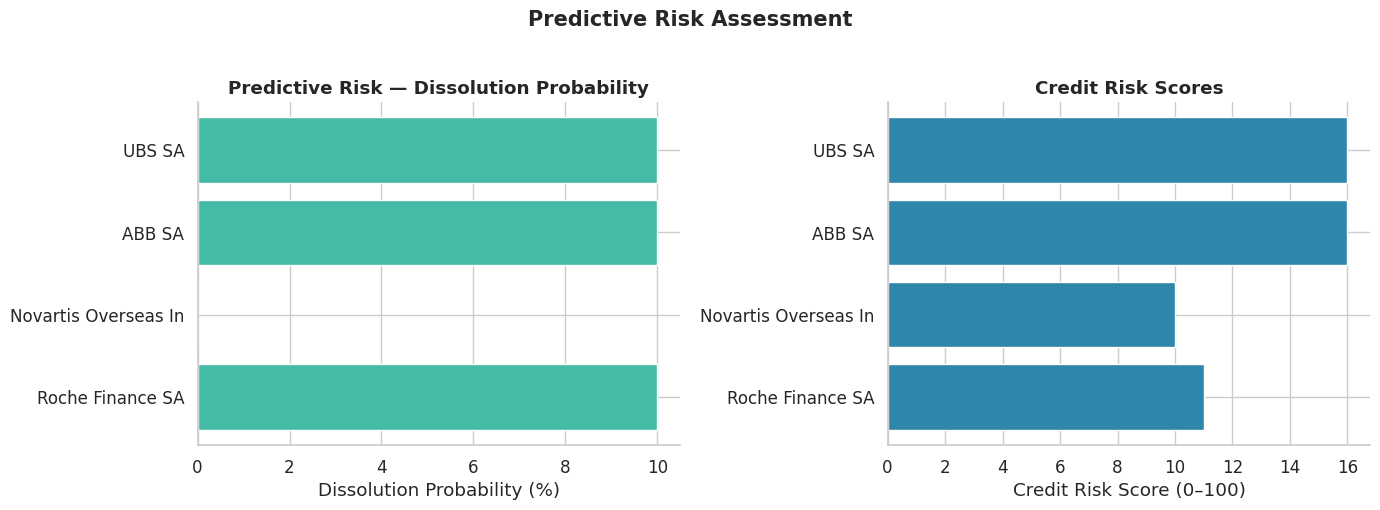

In [4]:
risk_results = []
for q in ["UBS", "ABB", "Novartis", "Roche"]:
    r = client.companies.list(query=q, page_size=1)
    if r.data.items:
        uid = r.data.items[0].uid
        risk = client.ai.predictive_risk(uid=uid).data
        risk_results.append(risk)
        print(f"  {risk.company_name:<40} prob={risk.dissolution_probability:>5.1f}%  "
              f"credit={risk.credit_risk_score:>3}  [{risk.risk_level}]")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Dissolution probability
names = [r.company_name[:20] for r in risk_results]
probs = [r.dissolution_probability for r in risk_results]
level_colors = {"low": "#44bba4", "medium": "#f18f01", "high": "#e94f37", "critical": "#c73e1d"}
bar_colors = [level_colors.get(r.risk_level, "#999") for r in risk_results]

ax1.barh(names[::-1], probs[::-1], color=bar_colors[::-1], edgecolor="white")
ax1.set_xlabel("Dissolution Probability (%)")
ax1.set_title("Predictive Risk — Dissolution Probability", fontweight="bold")
ax1.spines[["top", "right"]].set_visible(False)

# Credit risk scores
credit_scores = [r.credit_risk_score for r in risk_results]
ax2.barh(names[::-1], credit_scores[::-1], color=ACCENT, edgecolor="white")
ax2.set_xlabel("Credit Risk Score (0–100)")
ax2.set_title("Credit Risk Scores", fontweight="bold")
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle("Predictive Risk Assessment", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/predictive_risk.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Sanctions Database Browser

Browse the SECO/OpenSanctions/FINMA sanctions databases directly.

In [5]:
sanctions = client.screening.browse_sanctions(page_size=20)
print(f"Total sanctions entries: {sanctions.data.total:,}")
print(f"\nFirst 10 entries:")
for s in sanctions.data.items[:10]:
    aliases = f" (aliases: {', '.join(s.aliases[:2])})" if s.aliases else ""
    print(f"  [{s.entity_type:<6}] {s.name:<40} program: {s.program}{aliases}")

# Search for specific entities
print(f"\nSearch 'bank':")
bank_sanctions = client.screening.browse_sanctions(search="bank", page_size=5)
for s in bank_sanctions.data.items:
    print(f"  {s.name} — {s.program} (listed since {s.listed_since or 'unknown'})")

Total sanctions entries: 5,910

First 10 entries:
  [entity] 140 Repair Plant JSC                     program: sanction (aliases: 140 ремонтный завод)
  [entity] 185th Center for Combat Use and Combat Purpose of the Aerospace Forces “Ashuluk” program: sanction (aliases: 185-й Центр боевого применения и боевого предназначения ВКС “Ашулук”)
  [entity] 195 Repair Plant of Rocket and Artillery Weapons program: sanction (aliases: OPEN JOINT STOCK COMPANY “195 REPAIR PLANTS RACKET-ARTILLERY ARMS”, АКЦИОНЕРНОЕ ОБЩЕСТВО “195 РЕМОНТНЫЙ ЗАВОД РАКЕТНО-АРТИЛЛЕРИЙСКОГО ВООРУЖЕНИЯ")
  [entity] 20th Guards Combined Arms Army           program: sanction (aliases: 20-я гвардейская Краснознаменная общевойсковая армия, 20-я гвардейская общевойсковая армия)
  [entity] 22nd Guards Heavy Bomber Aviation Division program: 
  [entity] 2566 Radioelectronic Armament Repair Plant program: sanction (aliases: ОАО “2566 ЗРРЭВ”, 2566 завод по ремонту радиоэлектронного вооружения)
  [entity] 27th Central Scientific R

## 5. Saved Searches & Pipelines

Demonstrate the CRM-style workflow: save a search, create a pipeline,
add prospects.

In [6]:
# Create a saved search
search = client.saved_searches.create(
    name="Large ZH Fintechs",
    search_params={"canton": "ZH", "industry": "fintech", "capitalMin": 1000000},
    description="Zurich-based fintech companies with >1M capital",
)
print(f"Created saved search: {search.data.name} (id: {search.data.id})")

# List saved searches
all_searches = client.saved_searches.list()
print(f"Total saved searches: {len(all_searches.data)}")

# Clean up
client.saved_searches.delete(search.data.id)
print(f"Deleted saved search: {search.data.name}")

Created saved search: Large ZH Fintechs (id: 61a755d1-751b-4dab-9b88-9801b50f89be)
Total saved searches: 1


Deleted saved search: Large ZH Fintechs
